In [1]:
%load_ext autoreload
%autoreload 2

import sys, json, time
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt

from src import config as cfg, data, adaboost, tuning

splits = {name: data.get_split(name) for name in cfg.DATASETS}


Spambase: 4601 rows, 391 duplicates removed


In [2]:
def brute_force(X,y,p):
    return min(p@(adaboost.stump_predict(X,j,tau,s) != y) for j in range (X.shape[1]) for tau in np.r_[-np.inf, X[:, j]] for s in (1,-1))

rng = np.random.default_rng(0)
X, y = splits["spambase"]["X_train"][:60, :8], splits["spambase"]["y_train"][:60]
p = rng.random(60)
p /= p.sum()
j,tau, s, eps = adaboost.best_stump(*adaboost.presort(X), p,y)

print(f"find eps = {eps:.6f}, recalculated = {p @ (adaboost.stump_predict(X, j, tau, s) != y):.6f}, "
      f"brute force = {brute_force(X, y, p):.6f}")

find eps = 0.159590, recalculated = 0.159590, brute force = 0.159590


In [3]:
for name, s in splits.items():
    X, y = s["X_train"], s["y_train"]
    t0 = time.perf_counter()
    model = adaboost.fit(X,y, cfg.T_MAX, store_weights=True)
    elapsed = time.perf_counter() -t0
    W, eps = model["weights"], model["eps"]
    H = np.array([adaboost.stump_predict(X,j,tau,sg) for j, tau, sg in zip(model["feature"], model["threshold"], model["polarity"])])
    F = adaboost.staged_scores(model, X)
    bound = np.cumprod(2*np.sqrt(eps*(1-eps)))
    train_err = np.mean(adaboost.sgn(F) != y, axis=1)
    print(f"\n{name}: T = {len(eps)}, fit in {elapsed:.1f}s")
    print(f"  |eps recalculated - eps|          max = {np.abs((W[:-1] * (H != y)).sum(1) - eps).max():.1e}")
    print(f"  |error of h_t below p^(t+1) - 1/2| max = {np.abs((W[1:] * (H != y)).sum(1) - 0.5).max():.1e}")
    print(f"  |exp-loss of F/2 - bound|         max = {np.abs(np.exp(-0.5 * y * F).mean(1) - bound).max():.1e}")
    print(f"  training error <= bound for each t: {np.all(train_err <= bound)}, "
          f"final training error = {train_err[-1]:.3f}, eps max = {eps.max():.3f}")


spambase: T = 500, fit in 3.0s
  |eps recalculated - eps|          max = 1.1e-14
  |error of h_t below p^(t+1) - 1/2| max = 1.7e-14
  |exp-loss of F/2 - bound|         max = 1.9e-14
  training error <= bound for each t: True, final training error = 0.042, eps max = 0.487

oblique: T = 500, fit in 0.1s
  |eps recalculated - eps|          max = 1.1e-15
  |error of h_t below p^(t+1) - 1/2| max = 1.2e-15
  |exp-loss of F/2 - bound|         max = 1.7e-15
  training error <= bound for each t: True, final training error = 0.117, eps max = 0.491

circles: T = 500, fit in 0.1s
  |eps recalculated - eps|          max = 1.0e-15
  |error of h_t below p^(t+1) - 1/2| max = 1.0e-15
  |exp-loss of F/2 - bound|         max = 7.8e-16
  training error <= bound for each t: True, final training error = 0.131, eps max = 0.491

xor: T = 500, fit in 0.1s
  |eps recalculated - eps|          max = 2.2e-16
  |error of h_t below p^(t+1) - 1/2| max = 2.2e-16
  |exp-loss of F/2 - bound|         max = 1.2e-15
  tra

In [4]:
best, cv = {}, {}

for name, s in splits.items():
    t0 = time.perf_counter()
    best[name], cv[name] = tuning.tune(s)
    b, ada = best[name], cv[name]["adaboost"].mean(axis=0)
    print(f"\n{name} ({time.perf_counter() - t0:.0f}s)")
    print(f"  AdaBoost: T* = {b['T']}, CV err = {ada[b['T'] - 1]:.3f} (single stump: {ada[0]:.3f})")
    print(f"  decision tree:   {b['tree']}, CV err = {min(r['mean'] for r in cv[name]['tree']):.3f}")
    print(f"  logistic regression:       {b['lr']}, CV err = {min(r['mean'] for r in cv[name]['lr']):.3f}")
    if b["T"] > 0.9 * cfg.T_MAX:
        print("  increase T_MAX")
    
    for model, grid in (("tree", cfg.TREE_GRID), ("lr", cfg.LR_GRID)):
        for key, val in b[model].items():
            if val in (grid[key][0], grid[key][-1]):
                print(f"  -> {model}: {key} = {val} border of grid")


spambase (16s)
  AdaBoost: T* = 54, CV err = 0.061 (single stump: 0.230)
  decision tree:   {'max_depth': 10, 'min_samples_leaf': 1}, CV err = 0.086
  logistic regression:       {'C': 1.0}, CV err = 0.065
  -> tree: min_samples_leaf = 1 border of grid

oblique (1s)
  AdaBoost: T* = 54, CV err = 0.160 (single stump: 0.247)
  decision tree:   {'max_depth': 5, 'min_samples_leaf': 1}, CV err = 0.144
  logistic regression:       {'C': 0.01}, CV err = 0.101
  -> tree: min_samples_leaf = 1 border of grid

circles (1s)
  AdaBoost: T* = 122, CV err = 0.146 (single stump: 0.385)
  decision tree:   {'max_depth': 5, 'min_samples_leaf': 10}, CV err = 0.167
  logistic regression:       {'C': 0.1}, CV err = 0.364

xor (1s)
  AdaBoost: T* = 61, CV err = 0.452 (single stump: 0.495)
  decision tree:   {'max_depth': 5, 'min_samples_leaf': 10}, CV err = 0.113
  logistic regression:       {'C': 0.1}, CV err = 0.393


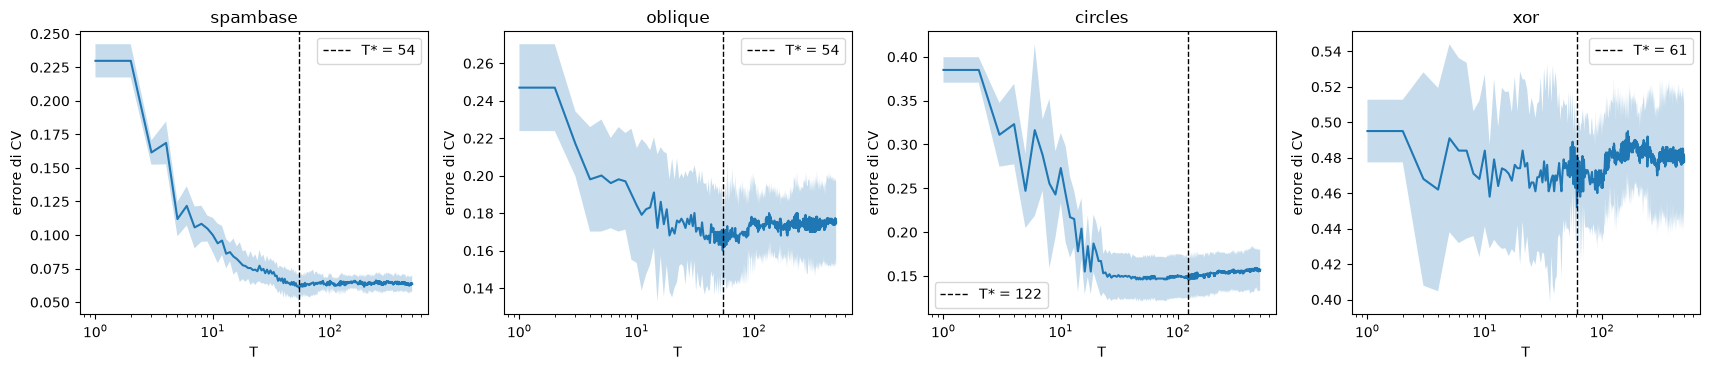

In [5]:
t = np.arange(1, cfg.T_MAX + 1)
fig, axes = plt.subplots(1, len(cfg.DATASETS), figsize=(4.3 * len(cfg.DATASETS), 3.8)) 
for ax, name in zip(axes, cfg.DATASETS):
    c = cv[name]["adaboost"]
    mean, std = c.mean(axis=0), c.std(axis=0)
    ax.plot(t, mean, lw=1.5)
    ax.fill_between(t, mean - std, mean + std, alpha=0.25)
    ax.axvline(best[name]["T"], color="k", ls="--", lw=1, label=f"T* = {best[name]['T']}")
    ax.set(xscale="log", title=name, xlabel="T", ylabel="errore di CV")
    ax.legend()
fig.tight_layout()
#fig.savefig(cfg.FIG_DIR / "cv_adaboost.pdf", bbox_inches="tight")
plt.show()

In [6]:
with open(cfg.RESULTS_DIR / f"hyperparams_seed{cfg.SEED}.json", "w") as f:
    json.dump(best, f, indent=2)